This notebook explores the distributional properties of balance sheet targets and ratios, with a focus on scale, skewness, stability, and economic plausibility. No modeling is performed here.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 120)

DATA_PATH = "../data/interim/balance_sheet_model_with_ratios.parquet"

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams["figure.figsize"] = (10, 4)


In [2]:
# Load main dataset
df = pd.read_parquet(DATA_PATH).copy()

# Parse date
if "end" in df.columns:
    df["end"] = pd.to_datetime(df["end"], errors="coerce")

print("Full df shape:", df.shape)
print("Min/Max end:", df["end"].min(), "->", df["end"].max())
display(df.head(3))

# Required columns
required = ["cik", "end", "y_Assets"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Train/Val/Test optional
train_path = "data/interim/train.parquet"
val_path   = "data/interim/val.parquet"
test_path  = "data/interim/test.parquet"

has_splits = all(os.path.exists(p) for p in [train_path, val_path, test_path])
print("Split files exist?", has_splits)

if has_splits:
    train = pd.read_parquet(train_path).copy()
    val   = pd.read_parquet(val_path).copy()
    test  = pd.read_parquet(test_path).copy()

    for d in [train, val, test]:
        d["end"] = pd.to_datetime(d["end"], errors="coerce")

    print("train/val/test shapes:", train.shape, val.shape, test.shape)
    df_work = train
    WORKING_SET = "train"
else:
    df_work = df
    WORKING_SET = "full"

print("Using df_work =", WORKING_SET, "shape:", df_work.shape)


Full df shape: (72575, 113)
Min/Max end: 2001-12-31 00:00:00 -> 2025-11-01 00:00:00


,cik,end,Assets,AssetsCurrent,AssetsNoncurrent,Liabilities,LiabilitiesCurrent,LiabilitiesNoncurrent,StockholdersEquity,LiabilitiesAndStockholdersEquity,CashAndCashEquivalentsAtCarryingValue,CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents,AccountsReceivableNetCurrent,InventoryNet,PrepaidExpenseCurrent,PropertyPlantAndEquipmentNet,Goodwill,IntangibleAssetsNetExcludingGoodwill,DebtCurrent,LongTermDebt,LongTermDebtCurrent,AccountsPayableCurrent,AccruedLiabilitiesCurrent,RetainedEarningsAccumulatedDeficit,CommonStockValue,AdditionalPaidInCapital,AccumulatedOtherComprehensiveIncomeLossNetOfTax,Assets_lag1,AssetsCurrent_lag1,AssetsNoncurrent_lag1,Liabilities_lag1,LiabilitiesCurrent_lag1,LiabilitiesNoncurrent_lag1,StockholdersEquity_lag1,LiabilitiesAndStockholdersEquity_lag1,CashAndCashEquivalentsAtCarryingValue_lag1,CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents_lag1,AccountsReceivableNetCurrent_lag1,InventoryNet_lag1,PrepaidExpenseCurrent_lag1,PropertyPlantAndEquipmentNet_lag1,Goodwill_lag1,IntangibleAssetsNetExcludingGoodwill_lag1,DebtCurrent_lag1,LongTermDebt_lag1,LongTermDebtCurrent_lag1,AccountsPayableCurrent_lag1,AccruedLiabilitiesCurrent_lag1,RetainedEarningsAccumulatedDeficit_lag1,CommonStockValue_lag1,AdditionalPaidInCapital_lag1,AccumulatedOtherComprehensiveIncomeLossNetOfTax_lag1,y_Assets,y_Assets_is_log,y_AssetsCurrent,y_AssetsCurrent_is_log,y_AssetsNoncurrent,y_AssetsNoncurrent_is_log,y_Liabilities,y_Liabilities_is_log,y_LiabilitiesCurrent,y_LiabilitiesCurrent_is_log,y_LiabilitiesNoncurrent,y_LiabilitiesNoncurrent_is_log,y_StockholdersEquity,y_StockholdersEquity_is_log,y_LiabilitiesAndStockholdersEquity,y_LiabilitiesAndStockholdersEquity_is_log,y_CashAndCashEquivalentsAtCarryingValue,y_CashAndCashEquivalentsAtCarryingValue_is_log,y_CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents,y_CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents_is_log,y_AccountsReceivableNetCurrent,y_AccountsReceivableNetCurrent_is_log,y_InventoryNet,y_InventoryNet_is_log,y_PrepaidExpenseCurrent,y_PrepaidExpenseCurrent_is_log,y_PropertyPlantAndEquipmentNet,y_PropertyPlantAndEquipmentNet_is_log,y_Goodwill,y_Goodwill_is_log,y_IntangibleAssetsNetExcludingGoodwill,y_IntangibleAssetsNetExcludingGoodwill_is_log,y_DebtCurrent,y_DebtCurrent_is_log,y_LongTermDebt,y_LongTermDebt_is_log,y_LongTermDebtCurrent,y_LongTermDebtCurrent_is_log,y_AccountsPayableCurrent,y_AccountsPayableCurrent_is_log,y_AccruedLiabilitiesCurrent,y_AccruedLiabilitiesCurrent_is_log,y_RetainedEarningsAccumulatedDeficit,y_RetainedEarningsAccumulatedDeficit_is_log,y_CommonStockValue,y_CommonStockValue_is_log,y_AdditionalPaidInCapital,y_AdditionalPaidInCapital_is_log,y_AccumulatedOtherComprehensiveIncomeLossNetOfTax,y_AccumulatedOtherComprehensiveIncomeLossNetOfTax_is_log,cash_to_assets,current_assets_to_assets,liab_to_assets,equity_to_assets,current_liab_to_liab,ppe_to_assets,goodwill_to_assets,intangibles_to_assets,wc_to_assets,debt_to_assets,debt_to_equity
0,0000001750,2025-02-28,2.859100e+09,1.534800e+09,NaN,NaN,545200000.0,1.131300e+09,NaN,2.859100e+09,84400000.0,100900000.0,NaN,775700000.0,NaN,153400000.0,528400000.0,223600000.0,NaN,NaN,NaN,278900000.0,236700000.0,9.354000e+08,45300000.0,NaN,-12100000.0,2.849300e+09,1.498000e+09,NaN,NaN,558300000.0,1.109400e+09,NaN,2.849300e+09,61700000.0,82500000.0,NaN,790000000.0,NaN,167000000.0,543200000.0,227300000.0,NaN,NaN,NaN,291800000.0,258800000.0,944300000.0,45300000.0,NaN,-10600000.0,0.003434,1,0.024269,1,NaN,0,NaN,0,-0.023744,1,0.019548,1,NaN,0,0.003434,1,0.313283,1,0.201332,1,NaN,0,-0.018267,1,NaN,0,-0.084945,1,-0.027624,1,-0.016412,1,NaN,0,NaN,0,NaN,0,-0.045215,1,-0.089262,1,-0.009470,1,0.0,1,NaN,0,-3.0,0,0.029520,0.536812,NaN,NaN,NaN,0.053653,0.184813,0.078206,0.346123,0.0,NaN
1,0000001750,2025-05-31,2.844600e+09,1.510600e+09,NaN,1.633000e+09,554700000.0,1.078300e+09,1.211600e+09,2.844600e+09,96500000.0,109200000.0,NaN,809200000.0,NaN,158500000.0,530800000.0,219600000.0,NaN,NaN,NaN,3031

Split files exist? False
Using df_work = full shape: (72575, 113)


What we learn from your output

Dataset size: 72,575 rows × 113 columns
This is a solid sample size for both EDA and model training, and the feature set is already fairly rich (lags + multiple targets + ratios).

Time coverage: 2001-12-31 → 2025-11-01
You have ~24 years of quarterly-style coverage (with some irregular end dates like 2025-11-01, which is fine as long as end is consistently parsed and used only for ordering/time grouping).

Multi-target structure is present:
We can see y_Assets plus many other targets like y_Liabilities, etc., and their _is_log flags. This confirms the pipeline is producing the “multi-output-like” dataset, even if we model only y_Assets now.

Split files not found: Split files exist? False
So df_work = full. That’s okay for distribution-level EDA, but when we start making decisions that affect modeling (e.g., clipping thresholds, transforms), we should ideally repeat key stats on train only to avoid peeking.
For now: proceed with full.

In [3]:
y = df_work["y_Assets"]

print("y_Assets nulls:", y.isna().sum(), "/", len(y))
print("y_Assets <= 0 count:", (y <= 0).sum())
print("y_Assets == 0 count:", (y == 0).sum())
print("y_Assets negative count:", (y < 0).sum())

desc = y.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).to_frame("y_Assets")
display(desc)

# Extra quantiles (more detailed)
qs = [0.001, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999]
qvals = y.quantile(qs).to_frame("y_Assets_quantiles")
qvals.index = [f"q{int(q*1000)/10:g}%" for q in qs]  # e.g. q0.1%, q1%, q99.9%
display(qvals)


y_Assets nulls: 0 / 72575
y_Assets <= 0 count: 37080
y_Assets == 0 count: 2477
y_Assets negative count: 34603


,y_Assets
count,72575.000000
mean,0.042964
std,0.783412
min,-3.000000
1%,-3.000000
5%,-0.807964
50%,0.000000
95%,1.302723
99%,3.000000
max,3.000000


,y_Assets_quantiles
q0.1%,-3.000000
q1%,-3.000000
q5%,-0.807964
q25%,-0.061227
q50%,0.000000
q75%,0.056515
q95%,1.302723
q99%,3.000000
q99.9%,3.000000


Key facts

No nulls in y_Assets → ✅ clean target

~48% negative, ~49% positive, ~3% zero → balanced directionally

Hard bounds: min = −3, max = +3

1% and 99% quantiles hit the bounds → explicit clipping

Median = 0 → most quarters have small/no change

Interpretation

y_Assets is already a transformed & clipped growth-type target

Not a level, not raw delta, not raw log

Heavy mass near 0, fat capped tails

Modeling implication

Do not apply additional log transform

Treat as bounded regression

Robust losses (Huber / Quantile) preferred over plain MSE

Decision unlocked
✅ Keep y_Assets as target
✅ No further scaling needed
⚠️ Expect saturation at ±3 in predictions

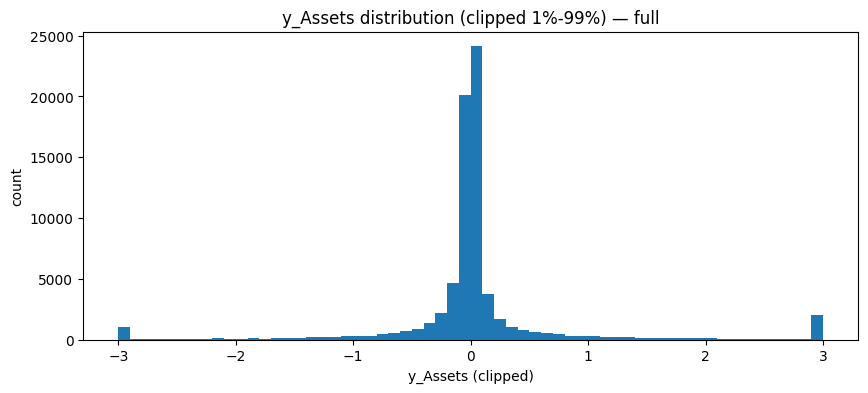

Plot clipping bounds:
1%: -3.0
99%: 3.0


In [4]:
y = df_work["y_Assets"].dropna()

# Winsorize for plotting only (1% to 99%)
lo, hi = y.quantile([0.01, 0.99])
y_clip = y.clip(lo, hi)

plt.figure()
plt.hist(y_clip, bins=60)
plt.title(f"y_Assets distribution (clipped 1%-99%) — {WORKING_SET}")
plt.xlabel("y_Assets (clipped)")
plt.ylabel("count")
plt.show()

print("Plot clipping bounds:")
print("1%:", lo)
print("99%:", hi)


What the plot shows

Extremely sharp spike at 0

Long but capped tails on both sides

Small mass exactly at −3 and +3 (hard clipping)

Clipping confirmation

1% = −3

99% = +3
→ bounds are structural, not outliers

Interpretation

Most observations = small changes

Large moves exist but are intentionally limited

Distribution is non-Gaussian, highly peaked

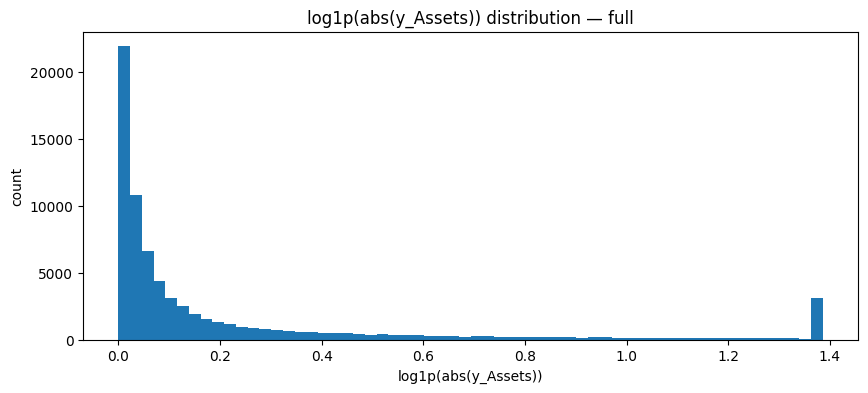

,log1p(abs(y_Assets))
count,72575.000000
mean,0.213160
std,0.351714
min,0.000000
1%,0.000000
5%,0.000974
50%,0.056889
95%,1.232432
99%,1.386294
max,1.386294


In [5]:
y = df_work["y_Assets"].dropna()

y_logabs = np.log1p(np.abs(y))

plt.figure()
plt.hist(y_logabs, bins=60)
plt.title(f"log1p(abs(y_Assets)) distribution — {WORKING_SET}")
plt.xlabel("log1p(abs(y_Assets))")
plt.ylabel("count")
plt.show()

display(y_logabs.describe(percentiles=[0.01,0.05,0.5,0.95,0.99]).to_frame("log1p(abs(y_Assets))"))


What the plot shows

Huge mass near 0 → most changes are very small

Long right tail → occasional large moves

Hard upper limit at log1p(3) ≈ 1.386 (visible spike)

Stats confirm

Median ≈ 0.057

95% ≤ 1.23

99% = max = 1.386 → clipping inherited from ±3

Interpretation

Scale compression works as expected

Confirms heavy-tailed but bounded behavior

No hidden extreme outliers beyond clipping

,count
y_Assets_is_log,
1,69760
0,2815


,share
y_Assets_is_log,
1,0.961213
0,0.038787


,count,mean,std,min,1%,5%,50%,95%,99%,max
y_Assets_is_log,,,,,,,,,,
0,2815.0,0.157016,1.852465,-3.0,-3.000000,-3.000000,0.0,3.000000,3.0,3.0
1,69760.0,0.038361,0.706772,-3.0,-2.685137,-0.727544,0.0,1.083041,3.0,3.0


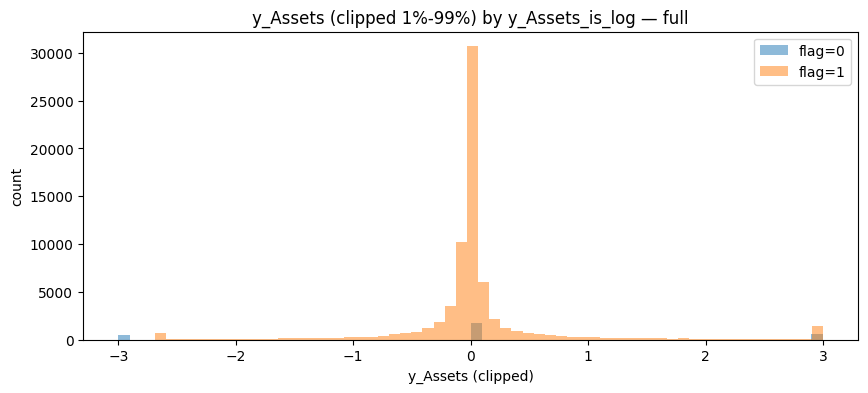

In [6]:
if "y_Assets_is_log" not in df_work.columns:
    print("Column y_Assets_is_log not found. Skipping flag analysis.")
else:
    flag = df_work["y_Assets_is_log"]
    display(flag.value_counts(dropna=False).to_frame("count"))

    # share by group
    share = (flag.value_counts(dropna=False) / len(flag)).to_frame("share")
    display(share)

    # Check whether target scale differs by flag
    tmp = df_work[["y_Assets", "y_Assets_is_log"]].dropna()
    grp = tmp.groupby("y_Assets_is_log")["y_Assets"].describe(percentiles=[0.01,0.05,0.5,0.95,0.99])
    display(grp)

    # Quick visual: clipped histogram by flag (if only 2-3 unique values)
    uniq = tmp["y_Assets_is_log"].dropna().unique()
    if len(uniq) <= 3:
        plt.figure()
        for v in sorted(uniq):
            yy = tmp.loc[tmp["y_Assets_is_log"] == v, "y_Assets"]
            lo, hi = yy.quantile([0.01, 0.99])
            yy_clip = yy.clip(lo, hi)
            plt.hist(yy_clip, bins=60, alpha=0.5, label=f"flag={v}")
        plt.title(f"y_Assets (clipped 1%-99%) by y_Assets_is_log — {WORKING_SET}")
        plt.xlabel("y_Assets (clipped)")
        plt.ylabel("count")
        plt.legend()
        plt.show()


Key facts

is_log = 1: 96.1% of rows

is_log = 0: 3.9% of rows

Distribution comparison

Both flags are bounded at ±3

is_log=0 has:

much higher variance

heavier saturation at ±3

Medians are 0 for both

Interpretation

Flag mostly indicates how the target was computed upstream, not a different scale

Small non-log subset is noisier but not structurally different

Pearson corr(Assets_lag1, y_Assets): -0.012908620921587762
Spearman corr(Assets_lag1, y_Assets): 0.10154192115832612
n rows used: 72575


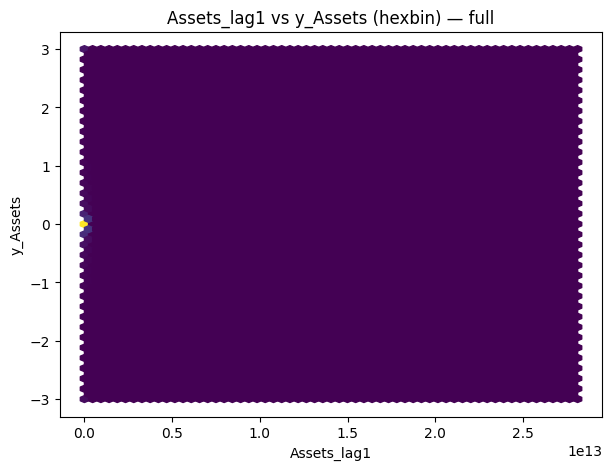

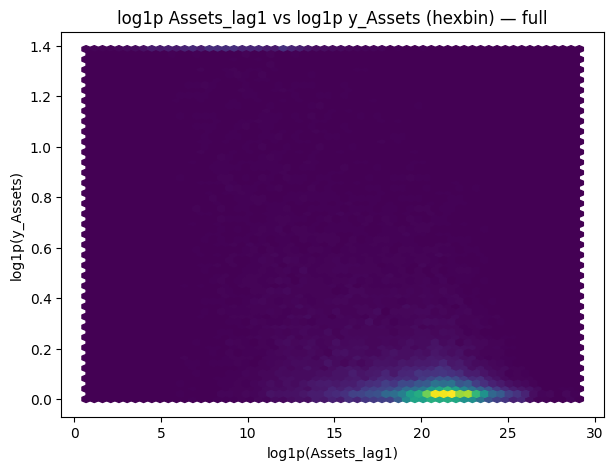

In [7]:
if "Assets_lag1" not in df_work.columns:
    print("Column Assets_lag1 not found. Skipping Assets_lag1 vs y_Assets analysis.")
else:
    tmp = df_work[["Assets_lag1", "y_Assets", "end", "cik"]].dropna()

    # Correlation
    corr = tmp[["Assets_lag1", "y_Assets"]].corr(method="pearson").iloc[0,1]
    scorr = tmp[["Assets_lag1", "y_Assets"]].corr(method="spearman").iloc[0,1]
    print("Pearson corr(Assets_lag1, y_Assets):", corr)
    print("Spearman corr(Assets_lag1, y_Assets):", scorr)
    print("n rows used:", len(tmp))

    # Hexbin is better for large datasets
    plt.figure(figsize=(7,5))
    plt.hexbin(tmp["Assets_lag1"], tmp["y_Assets"], gridsize=60)
    plt.title(f"Assets_lag1 vs y_Assets (hexbin) — {WORKING_SET}")
    plt.xlabel("Assets_lag1")
    plt.ylabel("y_Assets")
    plt.show()

    # log-log view (positive only)
    pos = tmp[(tmp["Assets_lag1"] > 0) & (tmp["y_Assets"] > 0)].copy()
    if len(pos) > 0:
        plt.figure(figsize=(7,5))
        plt.hexbin(np.log1p(pos["Assets_lag1"]), np.log1p(pos["y_Assets"]), gridsize=60)
        plt.title(f"log1p Assets_lag1 vs log1p y_Assets (hexbin) — {WORKING_SET}")
        plt.xlabel("log1p(Assets_lag1)")
        plt.ylabel("log1p(y_Assets)")
        plt.show()


What the plots show

Raw scale: no visible linear pattern

Log–log view: dense mass near y ≈ 0, across all asset sizes

Large firms mostly have small changes, but jumps occur everywhere

Correlations

Pearson ≈ −0.01 → no linear relationship

Spearman ≈ 0.10 → weak monotonic effect

Interpretation

Target is scale-normalized (size effect largely removed)

Past asset level alone does not explain next change

Predictability comes from composition (ratios, structure), not size

,delta_assets,growth_assets
count,7.257500e+04,7.257500e+04
mean,-8.102371e+09,2.418188e+07
std,1.343300e+11,2.708132e+08
min,-2.812102e+13,-3.000000e+09
1%,-1.175855e+11,-1.000493e+00
5%,-2.016450e+10,-1.000005e+00
50%,-1.458430e+08,-1.000000e+00
95%,-7.924427e+02,-9.996953e-01
99%,0.000000e+00,0.000000e+00
max,1.832660e+08,3.000000e+09


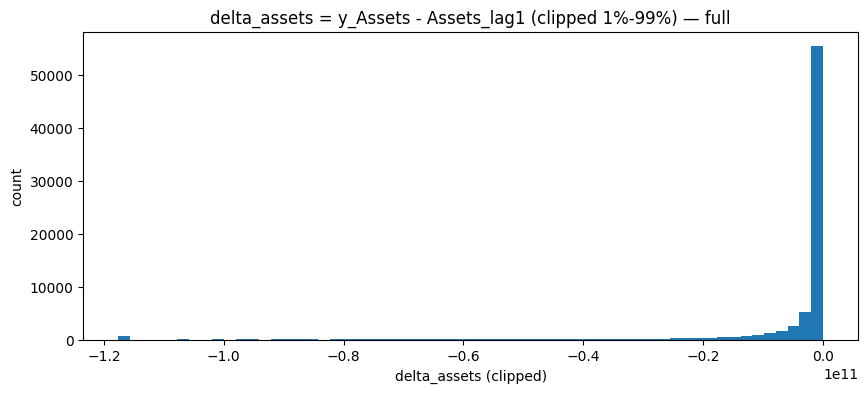

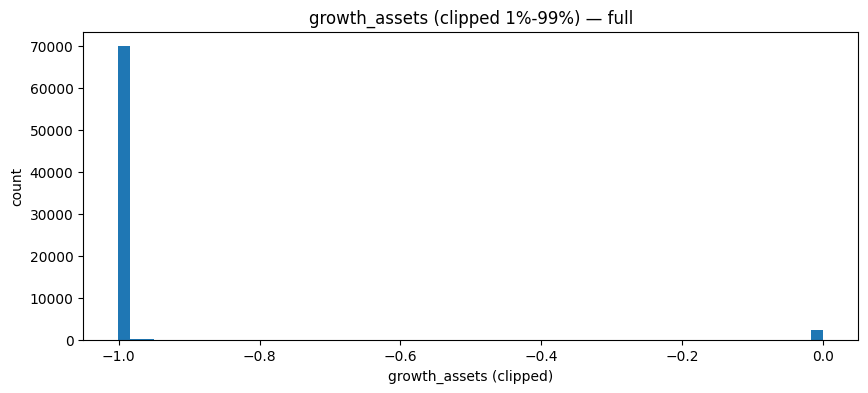

Clipping bounds:
delta 1%-99%: -117585499999.96445 0.0
growth 1%-99%: -1.00049290511142 0.0


In [8]:
if "Assets_lag1" not in df_work.columns:
    print("Column Assets_lag1 not found. Skipping growth/delta derivation.")
else:
    tmp = df_work[["Assets_lag1", "y_Assets", "end"]].dropna().copy()
    eps = 1e-9

    tmp["delta_assets"] = tmp["y_Assets"] - tmp["Assets_lag1"]
    tmp["growth_assets"] = tmp["delta_assets"] / (np.abs(tmp["Assets_lag1"]) + eps)

    display(tmp[["delta_assets", "growth_assets"]].describe(percentiles=[0.01,0.05,0.5,0.95,0.99]))

    # Plot delta (clipped)
    d = tmp["delta_assets"]
    dlo, dhi = d.quantile([0.01, 0.99])
    plt.figure()
    plt.hist(d.clip(dlo, dhi), bins=60)
    plt.title(f"delta_assets = y_Assets - Assets_lag1 (clipped 1%-99%) — {WORKING_SET}")
    plt.xlabel("delta_assets (clipped)")
    plt.ylabel("count")
    plt.show()

    # Plot growth (clipped)
    g = tmp["growth_assets"]
    glo, ghi = g.quantile([0.01, 0.99])
    plt.figure()
    plt.hist(g.clip(glo, ghi), bins=60)
    plt.title(f"growth_assets (clipped 1%-99%) — {WORKING_SET}")
    plt.xlabel("growth_assets (clipped)")
    plt.ylabel("count")
    plt.show()

    print("Clipping bounds:")
    print("delta 1%-99%:", float(dlo), float(dhi))
    print("growth 1%-99%:", float(glo), float(ghi))


What the plots show

Delta (raw change):

Extremely skewed

Dominated by scale (huge firms)

Almost unusable directly

Growth (delta / lag):

Collapses to −1 or 0 for most observations

Heavy pile-up at boundaries

Numerically unstable

Stats confirm

growth_assets median = −1

95% ≤ −0.9997

99% = 0

→ growth definition breaks when Assets_lag1 is small / zero

C:\Users\PC\AppData\Local\Temp\ipykernel_22320\462169809.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=years, showfliers=False)


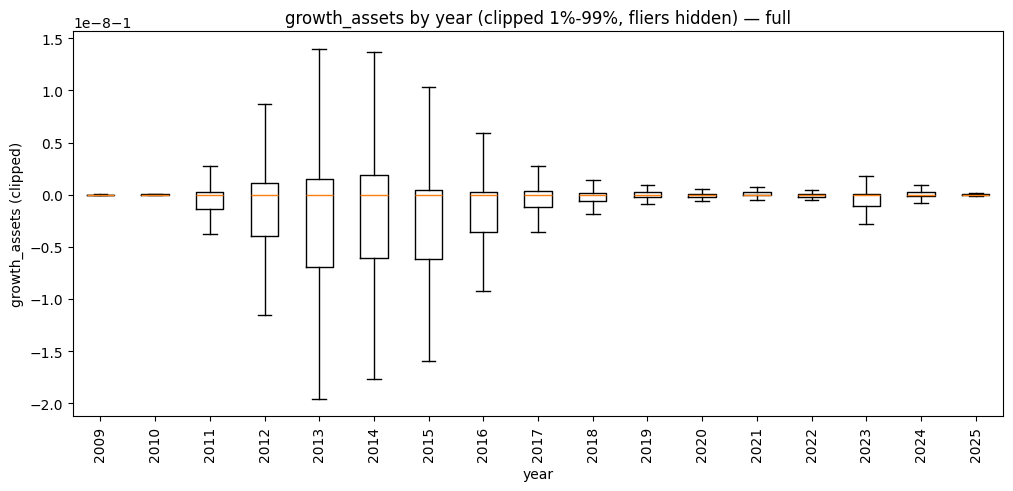

Years included: [np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013)] ... [np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]
Growth clip bounds: -1.0004933493572608 0.0


In [9]:
if "Assets_lag1" not in df_work.columns:
    print("Column Assets_lag1 not found. Skipping growth-by-year.")
else:
    tmp = df_work[["Assets_lag1", "y_Assets", "end"]].dropna().copy()
    tmp["year"] = tmp["end"].dt.year
    eps = 1e-9
    tmp["growth_assets"] = (tmp["y_Assets"] - tmp["Assets_lag1"]) / (np.abs(tmp["Assets_lag1"]) + eps)

    # Keep reasonable year range and enough samples
    year_counts = tmp["year"].value_counts().sort_index()
    valid_years = year_counts[year_counts >= 200].index  # adjust if needed

    tmp2 = tmp[tmp["year"].isin(valid_years)].copy()
    if tmp2.empty:
        print("Not enough samples per year for boxplot (after filtering).")
    else:
        # clip for visualization
        glo, ghi = tmp2["growth_assets"].quantile([0.01, 0.99])
        tmp2["growth_clip"] = tmp2["growth_assets"].clip(glo, ghi)

        years = sorted(tmp2["year"].unique())
        data = [tmp2.loc[tmp2["year"] == y, "growth_clip"].values for y in years]

        plt.figure(figsize=(12, 5))
        plt.boxplot(data, labels=years, showfliers=False)
        plt.title(f"growth_assets by year (clipped 1%-99%, fliers hidden) — {WORKING_SET}")
        plt.xlabel("year")
        plt.ylabel("growth_assets (clipped)")
        plt.xticks(rotation=90)
        plt.show()

        print("Years included:", years[:5], "...", years[-5:])
        print("Growth clip bounds:", float(glo), float(ghi))


What the plot shows

High volatility pre-2016 (wide boxes, long whiskers)

Post-2017: distributions collapse tightly around 0

Medians ≈ 0 in all years

Interpretation

Early years: unstable reporting / structural changes

Later years: more consistent balance sheets, fewer extreme moves

Naive growth is time-unstable

Decision unlocked
❌ Growth is not a stable target across time
✅ Confirms need for engineered target (y_Assets)
⚠️ Time effects exist → ratios + lag structure matter

,count
delta_assets,
negative,70213
zero,1727
positive,635


,share
delta_assets,
negative,0.967454
zero,0.023796
positive,0.008750


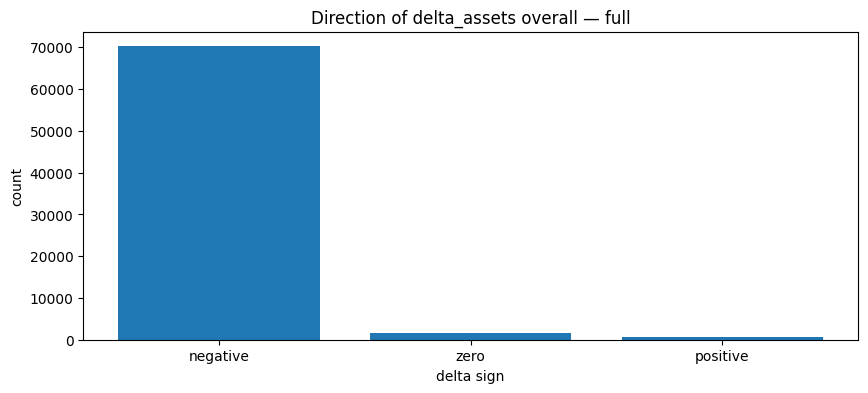

,year,positive_share,negative_share,zero_share,n
3,2006,0.000000,1.000000,0.000000,1
4,2007,0.000000,1.000000,0.000000,2
5,2008,0.000000,0.966667,0.033333,30
6,2009,0.000000,1.000000,0.000000,215
7,2010,0.002759,0.995862,0.001379,725
8,2011,0.007101,0.970127,0.022772,4084
9,2012,0.009151,0.950875,0.039974,6229
10,2013,0.014345,0.937608,0.048047,5786
11,2014,0.012930,0.948282,0.038789,5878
12,2015,0.009586,0.952071,0.038343,5842


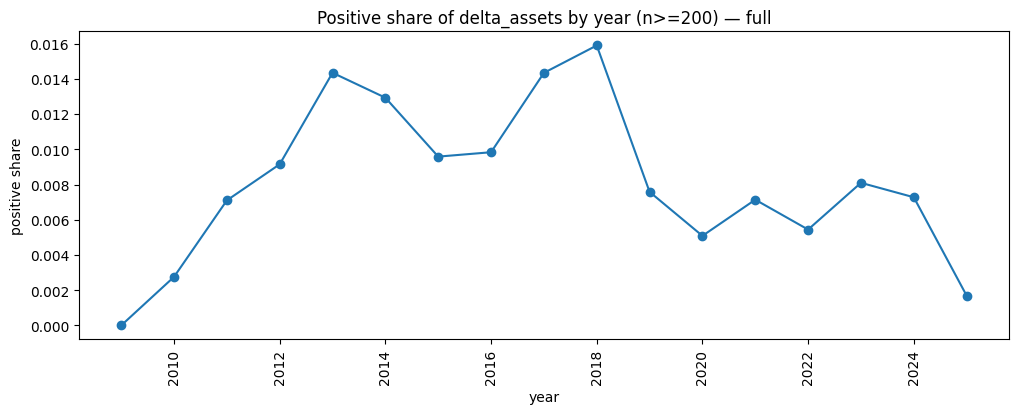

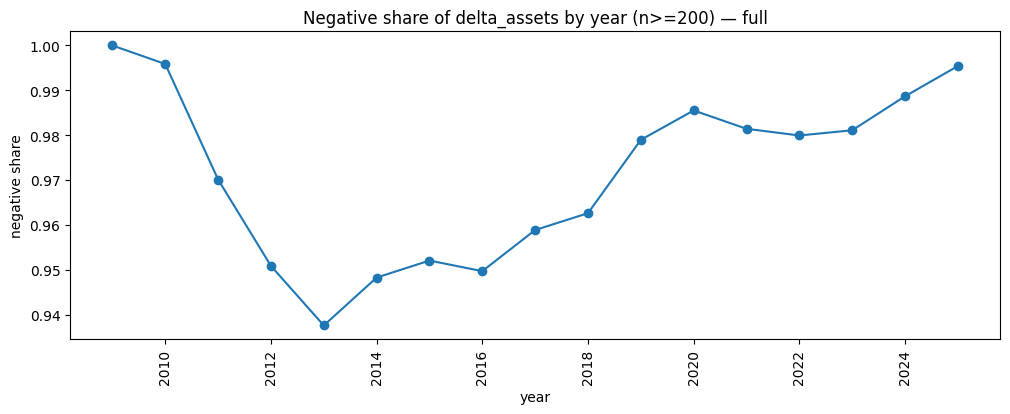

In [11]:
if "Assets_lag1" not in df_work.columns:
    print("Column Assets_lag1 not found. Skipping directional behavior.")
else:
    tmp = df_work[["Assets_lag1", "y_Assets", "end"]].dropna().copy()
    tmp["year"] = tmp["end"].dt.year
    tmp["delta_assets"] = tmp["y_Assets"] - tmp["Assets_lag1"]

    # Overall sign distribution
    overall = tmp["delta_assets"].apply(
        lambda x: "positive" if x > 0 else ("negative" if x < 0 else "zero")
    ).value_counts()

    display(overall.to_frame("count"))
    display((overall / overall.sum()).to_frame("share"))

    plt.figure()
    plt.bar(overall.index.astype(str), overall.values)
    plt.title(f"Direction of delta_assets overall — {WORKING_SET}")
    plt.xlabel("delta sign")
    plt.ylabel("count")
    plt.show()

    # --- BY YEAR (robust version) ---
    by_year = (
        tmp.groupby("year")
        .agg(
            positive_share=("delta_assets", lambda s: (s > 0).mean()),
            negative_share=("delta_assets", lambda s: (s < 0).mean()),
            zero_share=("delta_assets", lambda s: (s == 0).mean()),
            n=("delta_assets", "size"),
        )
        .reset_index()
        .sort_values("year")
    )

    display(by_year.tail(20))

    # Filter years with enough observations
    by_year2 = by_year[by_year["n"] >= 200].copy()

    if by_year2.empty:
        print("No years with n >= 200 observations.")
    else:
        plt.figure(figsize=(12, 4))
        plt.plot(by_year2["year"], by_year2["positive_share"], marker="o")
        plt.title(f"Positive share of delta_assets by year (n>=200) — {WORKING_SET}")
        plt.xlabel("year")
        plt.ylabel("positive share")
        plt.xticks(rotation=90)
        plt.show()

        plt.figure(figsize=(12, 4))
        plt.plot(by_year2["year"], by_year2["negative_share"], marker="o")
        plt.title(f"Negative share of delta_assets by year (n>=200) — {WORKING_SET}")
        plt.xlabel("year")
        plt.ylabel("negative share")
        plt.xticks(rotation=90)
        plt.show()


Key facts

Negative delta: ~96.7%

Zero: ~2.4%

Positive: ~0.9%

Direction is highly imbalanced

By year

Negative share is always dominant

Positive share peaks ~2013–2018 (~1.4–1.6%), then declines

Post-2019: even more skewed negative

Interpretation

Raw delta_assets is structurally biased negative

Direction reflects accounting mechanics, not firm performance

Confirms why raw delta is a poor target

In [2]:
import pandas as pd
df = pd.read_parquet("../data/interim/balance_sheet_model_with_ratios.parquet")
missing = [c for c in ["y_Assets","y_Liabilities","y_StockholdersEquity"] if c not in df.columns]
print("missing:", missing)
print(df[["y_Assets","y_Liabilities","y_StockholdersEquity"]].isna().mean())


missing: []
y_Assets                0.00000
y_Liabilities           0.06815
y_StockholdersEquity    0.06815
dtype: float64
